# Verification: Flow Past Periodic Array of Spheres

This notebook verifies the CFD solver by simulating flow through a simple cubic array of spheres at low Reynolds number ($Re \approx 0.01$).

We compare the computed Drag Coefficient ($K$) against reference values from Zick & Homsy (1982) and Sangani & Acrivos (1982).

## Objectives
1. **Parameter Sweep**: Calculate $K$ for solid volume fractions $\phi \in [0.05, 0.5]$.
2. **Grid Convergence**: Verify numerical convergence for the dense case $\phi=0.5$.
3. **Visualization**: Export flow fields to VTI and plot results.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import time

# Add build directory to path to import pnm_backend
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../build')))
import pnm_backend

# Ensure output directory exists
os.makedirs('output', exist_ok=True)

## Helper Functions

In [2]:
def generate_sc_sdf(phi, res_n, L=1.0):
    """Generates Signed Distance Field for a Simple Cubic array of spheres."""
    # Use (Nx, Ny, Nz) shape with Fortran-order (x varies fastest) for consistency with user preference
    dx = L/res_n
    x = np.linspace(0, L, res_n, endpoint=False) + 0.5 * dx
    y = np.linspace(0, L, res_n, endpoint=False) + 0.5 * dx
    z = np.linspace(0, L, res_n, endpoint=False) + 0.5 * dx
    
    # indexing='ij' gives shape (Nx, Ny, Nz)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    R = (phi * 3.0 / (4.0 * np.pi))**(1.0/3.0) * L
    
    xc, yc, zc = L/2, L/2, L/2
    dist = np.sqrt((X - xc)**2 + (Y - yc)**2 + (Z - zc)**2)
    sdf = dist - R
    
    # ravel(order='F') ensures we flatten (x,y,z) as x-fast, y-med, z-slow
    # which matches the C++ linear index: idx = z*ny*nx + y*nx + x
    return sdf.ravel(order='F').astype(np.float32), R, (dx, dx, dx)

def get_analytical_k(phi):
    """Returns reference Drag Factor K from Sangani & Acrivos (1982) for Simple Cubic."""
    phis = np.array([0.05, 0.10, 0.20, 0.30, 0.40, 0.50])
    ks   = np.array([4.95, 6.10, 9.10, 13.6, 21.6, 39.5])
    if phi < phis[0]: return 1.0 # Dilute limit approximation
    return np.interp(phi, phis, ks)

def save_vti(filename, res_int3, spacing_float3, u, v, w, p):
    """Saves field data to VTI format."""
    nx, ny, nz = res_int3.x, res_int3.y, res_int3.z
    dx, dy, dz = spacing_float3.x, spacing_float3.y, spacing_float3.z
    
    # Interpolate staggered velocity to cell centers for correct visualization
    # u_stag(i,j,k) is at i-1/2. u_cc(i) = 0.5 * (u(i) + u(i+1))
    
    # Reshape using Fortran order to get (Nx, Ny, Nz) shape [x, y, z]
    # This interprets the linear buffer (X-fast) correctly into [i,j,k]
    u_grid = u.reshape((nx, ny, nz), order='F')
    v_grid = v.reshape((nx, ny, nz), order='F')
    w_grid = w.reshape((nx, ny, nz), order='F')
    
    # Check periodicity logic: pnm_backend uses periodic wrapping
    # With shape [x, y, z]:
    # Axis 0 is X
    # Axis 1 is Y
    # Axis 2 is Z
    u_cc = 0.5 * (u_grid + np.roll(u_grid, -1, axis=0))
    v_cc = 0.5 * (v_grid + np.roll(v_grid, -1, axis=1))
    w_cc = 0.5 * (w_grid + np.roll(w_grid, -1, axis=2))
    
    # Flatten back to X-fast 1D streams for VTI writing
    u_flat = u_cc.ravel(order='F')
    v_flat = v_cc.ravel(order='F')
    w_flat = w_cc.ravel(order='F')

    with open(filename, 'w') as f:
        f.write('<?xml version="1.0"?>\n')
        f.write('<VTKFile type="ImageData" version="0.1" byte_order="LittleEndian">\n')
        f.write(f'  <ImageData WholeExtent="0 {nx-1} 0 {ny-1} 0 {nz-1}" Origin="0 0 0" Spacing="{dx} {dy} {dz}">\n')
        f.write(f'    <Piece Extent="0 {nx-1} 0 {ny-1} 0 {nz-1}">\n')
        f.write('      <PointData Scalars="Pressure" Vectors="Velocity">\n')
        
        f.write('        <DataArray type="Float32" Name="Velocity" NumberOfComponents="3" format="ascii">\n')
        # Writing loop can be slow for large files in python, but acceptable for validation cases
        for i in range(len(u_flat)):
            f.write(f"{u_flat[i]} {v_flat[i]} {w_flat[i]} ")
        f.write('\n        </DataArray>\n')
        
        f.write('        <DataArray type="Float32" Name="Pressure" NumberOfComponents="1" format="ascii">\n')
        for val in p:
            f.write(f"{val} ")
        f.write('\n        </DataArray>\n')
        
        f.write('      </PointData>\n')
        f.write('    </Piece>\n')
        f.write('  </ImageData>\n')
        f.write('</VTKFile>\n')
    print(f"Saved {filename}")

## Simulation Kernel

In [5]:
class SimulationRunner:
    def __init__(self, phi, res_n, L=1.0):
        self.phi = phi
        self.res_n = res_n
        self.L = L
        
        self.sdf_values, self.R, self.spacing_tuple = generate_sc_sdf(phi, res_n, L)
        self.dx, self.dy, self.dz = self.spacing_tuple
        
        # Setup Data Objects
        self.sdf_data = pnm_backend.SDFData(
            self.sdf_values, 
            pnm_backend.int3(res_n, res_n, res_n),
            pnm_backend.float3(0,0,0),
            pnm_backend.float3(self.dx, self.dy, self.dz)
        )
        self.solver = pnm_backend.CFDSolver(
            pnm_backend.int3(res_n, res_n, res_n), 
            pnm_backend.float3(self.dx, self.dy, self.dz)
        )
        self.solver.initialize(self.sdf_data)
        
        # Parameters (Low Re)
        self.rho = 1e0
        self.mu = 34.0
        self.f_mag = 1.0
        self.solver.set_body_force(pnm_backend.float3(self.f_mag, 0, 0))
        self.solver.set_rho(self.rho)
        self.solver.set_mu(self.mu)
        
        # Solver Parameters for Implicit Scheme
        self.solver.set_pressure_solver_params(200, 1e-16)
        self.solver.set_velocity_solver_params(200, 1e-16)
        self.solver.set_outer_iterations(20)

    def run(self, dt=1.0, max_steps=10000, save_output=False, filename=None):
        # Explicit limit is roughly 0.5*dx^2/nu ~ 0.5 * (1/64)^2 / 0.01 ~ 0.01
        # We use a much larger step to speed up convergence to steady state.
        
        u_mean_history = []
        
        print(f"Running phi={self.phi:.3f}, Res={self.res_n}^3, dt={dt:.4f}...")
        
        start_time = time.time()
        for i in range(max_steps):
            # Use Implicit Step
            self.solver.step(dt)
            
            if i % 50 == 0:
                u_field = np.array(self.solver.get_u())
                u_mean = np.mean(u_field)
                u_mean_history.append(u_mean)
                
                if len(u_mean_history) > 5:
                    # Relative change convergence check
                    if abs(u_mean_history[-1]) > 1e-12:
                        err = abs(u_mean_history[-1] - u_mean_history[-2]) / abs(u_mean_history[-1])
                        if err < 1e-5:
                            print(f"  Converged at step {i}. Mean Vel = {u_mean:.6e}")
                            break
        
        elapsed = time.time() - start_time
        u_field = np.array(self.solver.get_u())
        U_sup = np.mean(u_field)
        
        # Calculate K
        F_drag = self.f_mag * (self.L**3)
        K = F_drag* (1-self.phi) / (6.0 * np.pi * self.mu * self.R * U_sup)
        
        print(f"  K_sim = {K:.4f} (Time: {elapsed:.2f}s)")
        
        if save_output and filename:
            v = np.array(self.solver.get_v())
            w = np.array(self.solver.get_w())
            p = np.array(self.solver.get_p())
            save_vti(filename, pnm_backend.int3(self.res_n, self.res_n, self.res_n), pnm_backend.float3(self.dx, self.dy, self.dz), u_field, v, w, p)
            
        return K, U_sup

## 1. Parameter Sweep

In [6]:
phis = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
res_n = 32

results = []

for phi in phis:
    simulator = SimulationRunner(phi, res_n)
    k_sim, u_sup = simulator.run(save_output=True, filename=f"output/final_phi_{phi:.2f}.vti", dt = 1.0, max_steps=100)
    k_ref = get_analytical_k(phi)
    results.append({
        'phi': phi,
        'k_sim': k_sim,
        'k_ref': k_ref,
        'error': 100*(k_sim - k_ref)/k_ref
    })

# Output Table
print("\nSummary Results:")
print(f"{'Phi':<10} {'K_sim':<10} {'K_ref':<10} {'Error %':<10}")
print("-"*40)
for res in results:
    print(f"{res['phi']:<10.3f} {res['k_sim']:<10.4f} {res['k_ref']:<10.4f} {res['error']:<10.2f}")

Running phi=0.050, Res=32^3, dt=1.0000...IBM Geometry Updated.
  Pressure/Center: 
632
  U-Face: 604
  V-Face: 604
  W-Face: 604
  K_sim = 2.0447 (Time: 17.95s)
Saved output/final_phi_0.05.vti
Running phi=0.100, Res=32^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 968
  U-Face: 944
  V-Face: 944
  W-Face: 944
  K_sim = 2.8268 (Time: 22.10s)
Saved output/final_phi_0.10.vti
Running phi=0.200, Res=32^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 1512
  U-Face: 1484
  V-Face: 1484
  W-Face: 1484
  K_sim = 4.5264 (Time: 21.60s)
Saved output/final_phi_0.20.vti
Running phi=0.300, Res=32^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 1944
  U-Face: 1916
  V-Face: 1916
  W-Face: 1916
  K_sim = 6.6252 (Time: 20.05s)
Saved output/final_phi_0.30.vti
Running phi=0.400, Res=32^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 2336
  U-Face: 2356
  V-Face: 2356
  W-Face: 2356
  K_sim = 9.2548 (Time: 20.49s)
Saved output/final_phi_0.40.vti
Running phi=0.500, Res=

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_415808/2110517439.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('Solid Volume Fraction $\phi$')


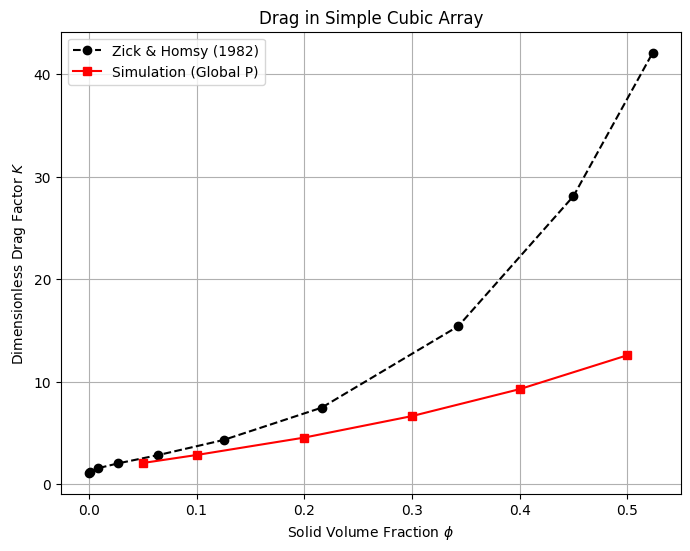

In [7]:
# Plotting
phi_vals = [r['phi'] for r in results]
k_sims = [r['k_sim'] for r in results]
k_refs = [r['k_ref'] for r in results]
phi_Zick_Homsy = [0.000125, 0.001, 0.008, 0.027, 0.064, 0.125, 0.216, 0.343, 0.45, 0.5236]
k_Zick_Homsy = [1.096, 1.212, 1.525, 2.008, 2.810, 4.292, 7.442, 15.4, 28.1, 42.1]

plt.figure(figsize=(8, 6))
plt.plot(phi_Zick_Homsy, k_Zick_Homsy, 'k--o', label='Zick & Homsy (1982)')
plt.plot(phi_vals, k_sims, 'r-s', label='Simulation (Global P)')
plt.xlabel('Solid Volume Fraction $\phi$')
plt.ylabel('Dimensionless Drag Factor $K$')
plt.title('Drag in Simple Cubic Array')
plt.grid(True)
plt.legend()
plt.savefig('output/param_sweep_plot.png')
plt.show()

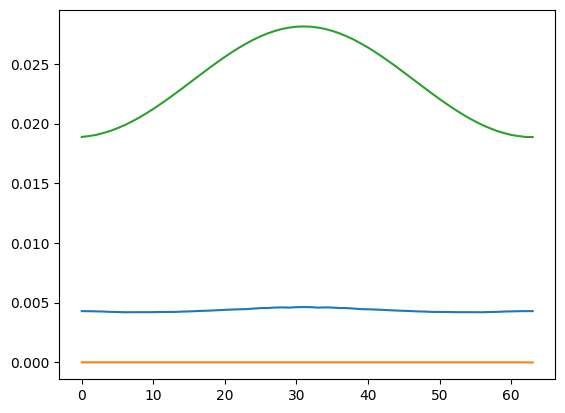

In [ ]:
u= np.array(simulator.solver.get_u())
u = u.reshape((res_n, res_n, res_n), order='F')
u_sup = np.mean(u,axis=(1,2))
plt.plot(u_sup)
plt.plot(u[:,res_n//2,res_n//2 ])
plt.plot(u[:,0,0])
plt.show()


## 2. Grid Convergence Study
We test resolution effects for the densest case.

<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_135664/1415492716.py:26: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f'Grid Convergence ($\phi={phi_dense}$)')


Running Grid Convergence for phi=0.4...
IBM Geometry Updated.
  Pressure/Center: Running phi=0.400, Res=32^3, dt=1.0000...
2336
  U-Face: 2356
  V-Face: 2356
  W-Face: 2356
  Converged at step 250. Mean Vel = 9.233505e-03
  K_sim = 7.5421 (Time: 4.61s)

Grid Convergence Results (phi=0.4):
N     K_sim     
---------------
32    7.5421    
Running phi=0.400, Res=64^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 9168
  U-Face: 9136
  V-Face: 9136
  W-Face: 9136
  Converged at step 250. Mean Vel = 7.663674e-03
  K_sim = 9.0870 (Time: 9.20s)

Grid Convergence Results (phi=0.4):
N     K_sim     
---------------
32    7.5421    
64    9.0870    
Running phi=0.400, Res=96^3, dt=1.0000...
IBM Geometry Updated.
  Pressure/Center: 20432
  U-Face: 20388
  V-Face: 20388
  W-Face: 20388
  Converged at step 250. Mean Vel = 6.715848e-03
  K_sim = 10.3695 (Time: 22.57s)

Grid Convergence Results (phi=0.4):
N     K_sim     
---------------
32    7.5421    
64    9.0870    
96    10.3695   
IBM

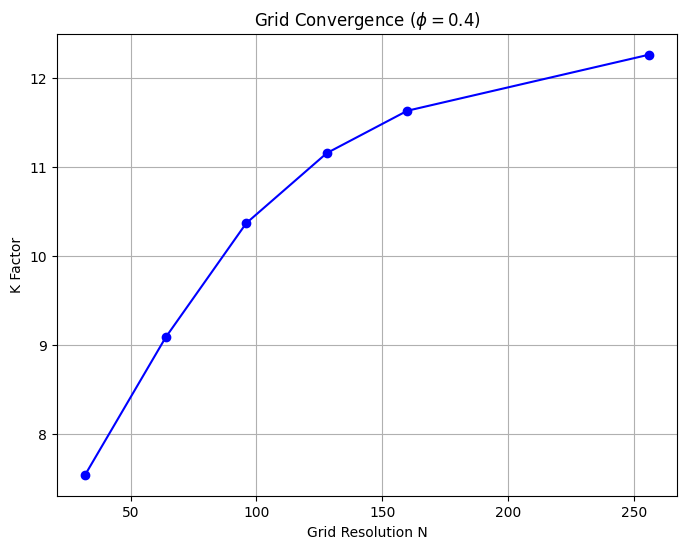

In [ ]:
phi_dense = 0.40
resolutions = [32, 64, 96, 128, 160, 256]

convergence_results = []

print(f"Running Grid Convergence for phi={phi_dense}...")
for res in resolutions:
    simulator = SimulationRunner(phi_dense, res)
    k_sim, _ = simulator.run(save_output=False)
    convergence_results.append((res, k_sim))

    print(f"\nGrid Convergence Results (phi={phi_dense}):")
    print(f"{'N':<5} {'K_sim':<10}")
    print("-" * 15)
    for r in convergence_results:
        print(f"{r[0]:<5} {r[1]:<10.4f}")

# Plot Convergence
res_vals = [r[0] for r in convergence_results]
k_vals = [r[1] for r in convergence_results]

plt.figure(figsize=(8, 6))
plt.plot(res_vals, k_vals, 'b-o')
plt.xlabel('Grid Resolution N')
plt.ylabel('K Factor')
plt.title(f'Grid Convergence ($\phi={phi_dense}$)')
plt.grid(True)
plt.savefig('output/grid_convergence.png')
plt.show()